In [1]:
import spacy
import re
import string
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from textblob import TextBlob
import gensim
from gensim import corpora


In [2]:
nlp=spacy.load("en_core_web_sm")

In [3]:
# Cargar la configuración desde el archivo
try:
    with open('config.json', 'r') as f:
        config = json.load(f)
except FileNotFoundError:
    config = {} # Usar configuración por defecto si el archivo no existe

num_palabras_nube = config.get('num_palabras_nube', 20)
colormap_nube = config.get('colormap_nube', 'autumn')
stopwords_excluir = config.get('stopwords_excluir', [])

In [4]:
# creamos una función de limpieza de texto con RegEx
def limpiar_texto(texto):
    texto = re.sub(r'[^a-zA-Z0-9áéíóúüñÁÉÍÓÚÜÑ\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


In [5]:
def procesar_texto(texto, nlp, stopwords_excluir=[]):
    doc = nlp(texto)
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and token.lemma_.lower() not in stopwords_excluir
    ]
    return tokens


In [6]:
def analizar_sentimiento(texto):
    analysis = TextBlob(texto)
    # polarity: -1 (negativo) a +1 (positivo)
    # subjectivity: 0 (objetivo) a 1 (subjetivo)
    return analysis.sentiment.polarity, analysis.sentiment.subjectivity


In [7]:
def identificar_entidades(texto, nlp):
    doc = nlp(texto)
    entidades = [(ent.text, ent.label_) for ent in doc.ents]
    return entidades


In [8]:
# descargamos 5 noticias
url_principal = 'https://www.scientificamerican.com/'
response_principal = requests.get(url_principal)
# comprobamos
response_principal


<Response [200]>

In [9]:
# parseamos, ordenamos el contenido con BeautifulSoup
soup_principal = BeautifulSoup(response_principal.text, 'html.parser')


In [11]:
num_articulos_extraer = int(input("¿Cuántos artículos deseas extraer? ")) + 1 # +1 para compensar el salto del primer artículo


¿Cuántos artículos deseas extraer?  5


In [12]:
def creacion_corpus(articulos, url_principal, limit=6):
    corpus_articulos = []
    for i, articulo in enumerate(articulos[1:limit]):
        enlace_tag = articulo.find('a', href=True)
        enlace = url_principal.rstrip('/') + enlace_tag['href']
        titulo = None
        contenido = None

        try:
            request = requests.get(enlace, timeout=10)
            request.raise_for_status()
            soup = BeautifulSoup(request.text, 'html.parser')

            titulo_tag = articulo.find('h2')
            if titulo_tag:
              titulo = titulo_tag.get_text(strip=True)

            cuerpo_articulo = soup.find_all('p')
            if cuerpo_articulo and len(cuerpo_articulo) > 2:
              contenido = ' '.join(p.get_text(strip=True) for p in cuerpo_articulo[2:])
            elif parrafos:
              contenido = ' '.join(p.get_text(strip=True) for p in parrafos)
            else:
              print(f"No se encontró el contenido del artículo en '{enlace}'")

            if titulo and contenido:
                polaridad, subjetividad = analizar_sentimiento(contenido)
                corpus_articulos.append({'titulo': titulo, 'contenido': contenido, 'polaridad': polaridad, 'subjetividad': subjetividad})
                entidades = identificar_entidades(contenido, nlp)
                corpus_articulos.append({'titulo': titulo, 'contenido': contenido, 'entidades': entidades})

        except requests.exceptions.RequestException as e:
            print(f"Error al acceder a la URL '{enlace}': {e}")
        except Exception as e:
            print(f"Error al procesar el contenido de '{enlace}': {e}")

    df_corpus = pd.DataFrame(corpus_articulos)
    df_corpus.to_json('corpus.json', orient='records', indent=4, force_ascii=False)
    print(f'El corpus tiene {len(corpus_articulos)} artículos guardados correctamente en df_corpus y corpus_json.')
    return corpus_articulos



In [13]:
# creamos el corpus
articulos = soup_principal.find_all('article', class_='article-pFLe7', limit=num_articulos_extraer)
corpus_articulos = creacion_corpus(articulos, url_principal, limit=num_articulos_extraer)


El corpus tiene 10 artículos guardados correctamente en df_corpus y corpus_json.


In [14]:
# mostramos el df
df_corpus = pd.DataFrame(corpus_articulos)
df_corpus.head()


,titulo,contenido,polaridad,subjetividad,entidades
0,AI Offers Digital Immortality for Deceased Lov...,AI chatbots called “griefbots” or “deadbots” o...,0.099207,0.413700,NaN
1,AI Offers Digital Immortality for Deceased Lov...,AI chatbots called “griefbots” or “deadbots” o...,NaN,NaN,"[(AI, ORG), (ByRachel Feltman, PERSON), (Naeem..."
2,This Impossible New Color Is So Rare That Only...,This Impossible New Color Is So Rare That Only...,0.115966,0.447681,NaN
3,This Impossible New Color Is So Rare That Only...,This Impossible New Color Is So Rare That Only...,NaN,NaN,"[(ByJacek Krywkoedited, PERSON), (Getty Images..."
4,Can There Be Sound in Space?,5min read Can There Be Sound in Space? It seem...,0.083652,0.437987,NaN


In [15]:
# convertimos los contenidos en una lista con la función .tolist() de numpy
corpus = df_corpus['contenido'].tolist()


In [16]:
def modelar_temas(corpus_procesado, num_temas=5):
    dictionary = corpora.Dictionary(corpus_procesado)
    corpus_gensim = [dictionary.doc2bow(text) for text in corpus_procesado]
    lda_model = gensim.models.LdaModel(corpus_gensim, num_topics=num_temas, id2word=dictionary, passes=15)
    temas = lda_model.print_topics(num_words=10)
    return temas


In [17]:
def procesar_corpus(corpus, nlp, stopwords_excluir=[]):
    corpus_procesado = []
    todas_las_palabras = []
    for texto in corpus:
        tokens = procesar_texto(texto, nlp, stopwords_excluir)
        corpus_procesado.append(tokens)
        todas_las_palabras.extend(tokens)
    frecuencia_palabras = Counter(todas_las_palabras)
    return corpus_procesado, frecuencia_palabras


In [18]:
corpus_procesado, frecuencia_palabras = procesar_corpus(corpus, nlp, stopwords_excluir)
palabras_top_nube = dict(frecuencia_palabras.most_common(num_palabras_nube))
palabras_top_nube

{'number': 68,
 'prime': 62,
 'space': 48,
 'feltman': 46,
 'card': 44,
 'scientific': 42,
 'american': 42,
 'idea': 42,
 'technology': 42,
 'magic': 40,
 'basińska': 38,
 'color': 38,
 'nowaczyk': 36,
 'like': 36,
 'new': 34,
 'think': 32,
 'use': 32,
 'sound': 32,
 'game': 32,
 'digital': 30}

In [19]:
temas = modelar_temas(corpus_procesado)
print("Temas encontrados:")
for tema_id, palabras in temas:
    print(f"Tema #{tema_id+1}: {palabras}")


Temas encontrados:
Tema #1: 0.001*"color" + 0.001*"cone" + 0.001*"number" + 0.001*"prime" + 0.001*"new" + 0.001*"light" + 0.001*"space" + 0.001*"american" + 0.001*"idea" + 0.001*"say"
Tema #2: 0.011*"feltman" + 0.011*"space" + 0.010*"technology" + 0.009*"basińska" + 0.008*"nowaczyk" + 0.007*"like" + 0.007*"digital" + 0.007*"sound" + 0.007*"particle" + 0.007*"american"
Tema #3: 0.001*"prime" + 0.001*"number" + 0.001*"space" + 0.001*"feltman" + 0.001*"magic" + 0.001*"idea" + 0.001*"like" + 0.001*"nowaczyk" + 0.001*"basińska" + 0.001*"technology"
Tema #4: 0.026*"color" + 0.019*"cone" + 0.018*"light" + 0.015*"ng" + 0.012*"human" + 0.012*"olo" + 0.012*"laser" + 0.012*"say" + 0.010*"new" + 0.008*"study"
Tema #5: 0.036*"number" + 0.034*"prime" + 0.025*"card" + 0.021*"magic" + 0.018*"game" + 0.016*"twin" + 0.012*"land" + 0.008*"infinite" + 0.007*"problem" + 0.007*"player"


In [20]:
# con colores de sol para simular el espacio y para jugar un poco
def crear_nube_palabras_redonda(frecuencias, num_palabras=20, colormap="autumn"):
    # creamos una máscara para dar la forma circular
    x, y = np.ogrid[:600, :600]
    center = (300, 300)
    radius = 280
    mask = (x - center[0])**2 + (y - center[1])**2 > radius**2
    mask = 255 * mask.astype(int)

    # creamos la nube de palabras
    wordcloud = WordCloud(
        width=600,
        height=600,
        background_color="black",
        colormap=colormap,
        max_words=num_palabras,
        mask=mask # le da la forma circular según creado en el párrafo anterior
    ).generate_from_frequencies(frecuencias)

    # mostramos la nube
    plt.figure(figsize=(6, 6))
    plt.imshow(wordcloud, interpolation="bilinear") # para suavizar bordes
    plt.axis("off")
    plt.show()

    # plt.savefig('wordcloud.jpg')


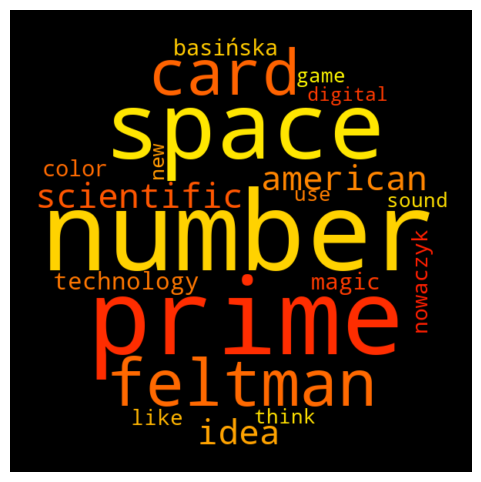

In [21]:
# hacemos la nube de palabras circular
crear_nube_palabras_redonda(palabras_top_nube, num_palabras=num_palabras_nube, colormap=colormap_nube)
